# Mental Health Intent Classification
Fine-tuning `distil-bert` for student query routing.

**Run cells top to bottom. After training, the model is saved to `../model/`.**

## 1. Install Dependencies

In [1]:
# Run this once, then restart kernel if needed
# !pip install transformers torch datasets scikit-learn pandas matplotlib seaborn

In [2]:
import subprocess, sys

packages = [
    "transformers",
    "torch",
    "datasets",
    "scikit-learn",
    "pandas",
    "matplotlib",
    "seaborn",
    "streamlit",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", *packages])


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


0

In [3]:
import os
print(os.getcwd())

/Users/kevinartan/Documents/GitHub/school_dashboard_administration/src


## 2. Imports

In [4]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
from collections import Counter # <-- ADD THIS IMPORT

import torch
from torch.utils.data import Dataset, DataLoader
# For distil-bert
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

/Users/kevinartan/Documents/GitHub/school_dashboard_administration/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 3. Load & Explore Data

In [5]:
# For Local Device:
JSON_PATH = Path.cwd().parent / "dataset" / "intents.json"
# For Google Colab:
# JSON_PATH = "dataset/intents.json"

# 1. Load and parse the JSON structured file
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

# 2. Parse patterns and tags into flat list rows
formatted_data = []
for intent in data['intents']:
    tag = intent['tag']
    for pattern in intent['patterns']:
        formatted_data.append({
            'text': pattern,
            'intent': tag
        })

# 3. Create a unified DataFrame
df = pd.DataFrame(formatted_data)

In [6]:
# ── Adjust these two lines to match your actual column names ──────────────
TEXT_COL  = 'text'
LABEL_COL = 'intent'
# ─────────────────────────────────────────────────────────────────────────

# 4. Encode string labels → integers
le = LabelEncoder()
df['label_id'] = le.fit_transform(df[LABEL_COL])

NUM_LABELS = len(le.classes_)
print(f'\nNumber of classes: {NUM_LABELS}')

print('\nClass mapping:')
for i, c in enumerate(le.classes_):
    print(f'  {i} → {c}')

# 5. Split cleanly into Train & Test (80% Train, 20% Test)
# Stratify keeps class representation uniform across both splits
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label_id']
)
# potential bug fix
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('\nTrain shape:', train_df.shape)
print('Test shape: ', test_df.shape)

# Debug view to ensure it matches your pipeline's expectations
print("\nFirst 5 rows of Train Data:")
print(train_df[[TEXT_COL, LABEL_COL, 'label_id']].head())


Number of classes: 9

Class mapping:
  0 → anger
  1 → depression
  2 → gratitude
  3 → greeting
  4 → loneliness
  5 → motivation
  6 → relationship
  7 → self_care
  8 → stress

Train shape: (1640, 3)
Test shape:  (410, 3)

First 5 rows of Train Data:
                                              text      intent  label_id
0                           I appreciate your time   gratitude         2
1            I appreciate your kindness and warmth   gratitude         2
2  I appreciate the comfort you bring into my life   gratitude         2
3        I feel like I'm just existing, not living  loneliness         4
4         I feel like I'm not a priority to anyone  loneliness         4


In [7]:
print(train_df.columns)

Index(['text', 'intent', 'label_id'], dtype='str')


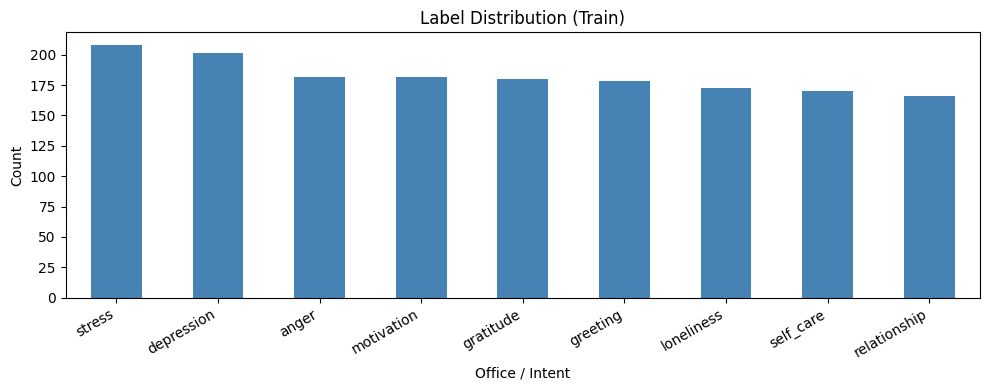

In [8]:
# Label distribution plot
plt.figure(figsize=(10, 4))
train_df[LABEL_COL].value_counts().plot(kind='bar', color='steelblue')
plt.title('Label Distribution (Train)')
plt.xlabel('Office / Intent')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [9]:
# Drop rows with missing text
train_df = train_df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
test_df  = test_df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
print('After dropping NaN — Train:', len(train_df), '| Test:', len(test_df))

After dropping NaN — Train: 1640 | Test: 410


## 5. Dataset & DataLoader

In [10]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 256
BATCH_SIZE = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.tolist()
        self.labels    = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = IntentDataset(train_df[TEXT_COL], train_df['label_id'], tokenizer, MAX_LEN)
test_dataset  = IntentDataset(test_df[TEXT_COL],  test_df['label_id'],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 52 | Test batches: 13


## 6. Model Setup

In [11]:
# For distil-bert
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
model = model.to(DEVICE)

EPOCHS    = 5
LR        = 2e-5

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f'Total training steps: {total_steps}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 23562.18it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total training steps: 260


## 7. Training

In [12]:
from tqdm.auto import tqdm

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in tqdm(loader, desc='Training'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # Extract cleanly using detach() and cpu()
        preds = outputs.logits.argmax(dim=1)

        # Debug print for first batch
        if total == 0:
            print("\nFirst batch predictions:")
            print(preds[:20].detach().cpu().numpy())
            print("First batch labels:")
            print(labels[:20].detach().cpu().numpy())

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()

            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

# Run standard clean loop
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    vl_loss, vl_acc = eval_epoch(model, test_loader, DEVICE)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch}/{EPOCHS} '
          f'| train loss {tr_loss:.4f} acc {tr_acc:.4f} '
          f'| val loss {vl_loss:.4f} acc {vl_acc:.4f}')

Training:   2%|▏         | 1/52 [00:02<02:32,  2.99s/it]


First batch predictions:
[0 2 3 0 2 0 0 5 2 2 5 5 2 8 0 2 0 0 0 2]
First batch labels:
[8 0 1 2 5 1 2 2 4 6 3 8 8 6 6 5 3 5 5 0]


Evaluating: 100%|██████████| 13/13 [00:06<00:00,  1.96it/s]


Epoch 1/5 | train loss 1.9456 acc 0.4159 | val loss 1.3777 acc 0.7732


Training:   2%|▏         | 1/52 [00:02<02:22,  2.79s/it]

...

Epoch 4/5 | train loss 0.4120 acc 0.9293 | val loss 0.3788 acc 0.9268


Training:   2%|▏         | 1/52 [00:02<02:03,  2.42s/it]


First batch predictions:
[0 0 8 1 3 5 0 7 7 3 2 3 0 3 5 4 7 1 3 4]
First batch labels:
[0 0 8 1 3 5 0 7 7 3 2 3 0 3 5 4 7 1 3 4]


Evaluating: 100%|██████████| 13/13 [00:07<00:00,  1.85it/s]

Epoch 5/5 | train loss 0.3392 acc 0.9427 | val loss 0.3526 acc 0.9293


## 8. Training Curves

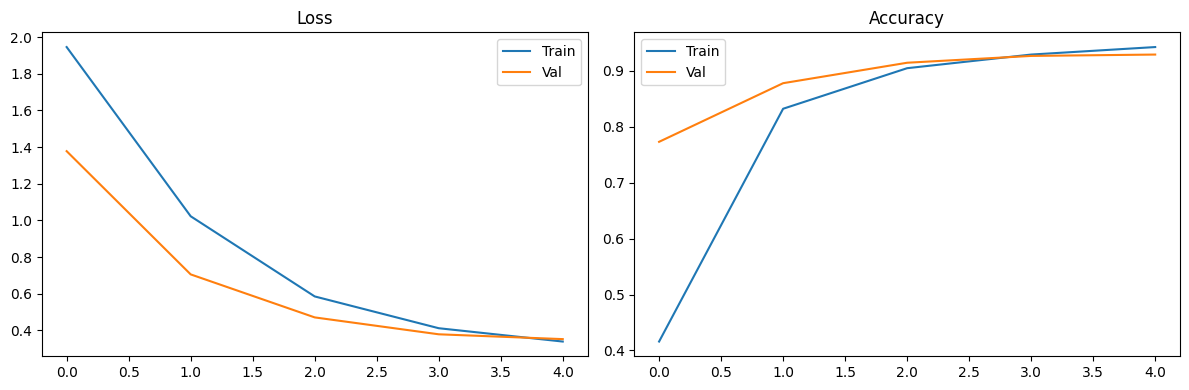

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
# Target unique folder for DISTIL-BERT
DISTIL_DIR = "./saved_distil_bert"
os.makedirs(DISTIL_DIR, exist_ok=True)

model.save_pretrained(DISTIL_DIR)
tokenizer.save_pretrained(DISTIL_DIR)
joblib.dump(le, os.path.join(DISTIL_DIR, "label_encoder.pkl"))
print(f"Successfully saved DISTIL-BERT weights to {DISTIL_DIR}!")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 18.04it/s]

Successfully saved DISTIL-BERT weights to ./saved_distil_bert!


## 9. Evaluation

In [15]:
# Inference

# FIX: Explicitly clear and initialize metric lists
all_preds = []
all_labels = []

model.eval()
# all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # Extract cleanly: move predictions to CPU and map to a NumPy array
        preds = outputs.logits.argmax(dim=1).detach().cpu().numpy()
        labels = batch['label'].numpy()  # Already on CPU as it is from standard batch dictionary

        # Use extend() with safe 1D numpy iterables
        all_preds.extend(preds)
        all_labels.extend(labels)

# Print tracking distributions to inspect variations
print("Prediction Distribution:")
print(Counter(all_preds))

print("\nTrue Label Distribution:")
print(Counter(all_labels))

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=le.classes_
))

Prediction Distribution:
Counter({np.int64(8): 53, np.int64(1): 51, np.int64(7): 46, np.int64(5): 45, np.int64(2): 45, np.int64(3): 44, np.int64(0): 42, np.int64(6): 42, np.int64(4): 42})

True Label Distribution:
Counter({np.int64(8): 52, np.int64(1): 50, np.int64(0): 46, np.int64(5): 45, np.int64(2): 45, np.int64(3): 44, np.int64(4): 43, np.int64(7): 43, np.int64(6): 42})

Classification Report:
              precision    recall  f1-score   support

       anger       0.93      0.85      0.89        46
  depression       0.80      0.82      0.81        50
   gratitude       1.00      1.00      1.00        45
    greeting       1.00      1.00      1.00        44
  loneliness       0.90      0.88      0.89        43
  motivation       0.96      0.96      0.96        45
relationship       1.00      1.00      1.00        42
   self_care       0.93      1.00      0.97        43
      stress       0.87      0.88      0.88        52

    accuracy                           0.93       410
   

In [16]:
all_preds.extend(preds)
all_labels.extend(batch['label'].numpy())

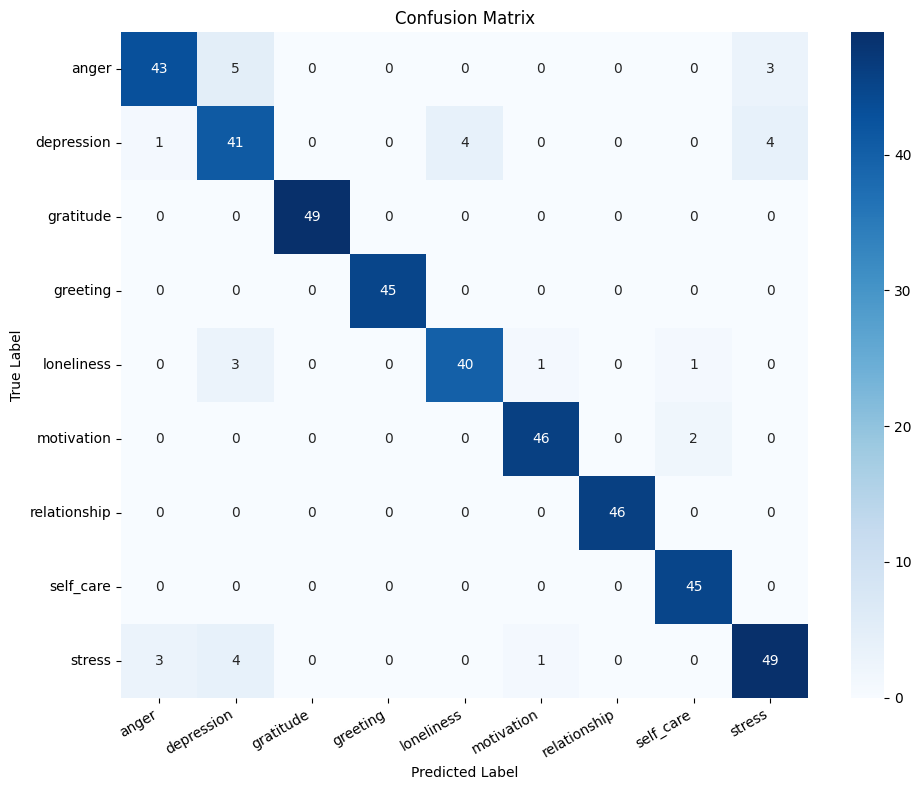

In [17]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 10. Quick Sanity Check
Test a few example queries before launching the app.

In [18]:
# 1. Setup the path where you saved this specific model
CHECK_DIR = "./saved_distil_bert"

print("Loading saved DISTIL-BERT model for live sanity check...")
loaded_tokenizer = AutoTokenizer.from_pretrained(CHECK_DIR)
loaded_model = AutoModelForSequenceClassification.from_pretrained(CHECK_DIR).to(DEVICE)
loaded_le = joblib.load(os.path.join(CHECK_DIR, "label_encoder.pkl"))

# 2. Refactored predict function using the LabelEncoder mapping
def predict(text, model, tokenizer, label_encoder, device, max_len=256):
    model.eval()
    enc = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        outputs = model(
            input_ids=enc['input_ids'].to(device),
            attention_mask=enc['attention_mask'].to(device)
        )
    pred_id = outputs.logits.argmax(dim=1).item()
    probs   = torch.softmax(outputs.logits, dim=1)[0].cpu().numpy()
    
    # Decode integer index back to text string label
    decoded_label = label_encoder.inverse_transform([pred_id])[0]
    return decoded_label, float(probs[pred_id])

# 3. Relevant mental health topic sample queries
sample_queries = [
    "Thank you so much for listening to me today, it helped a lot.",
    "I am having a massive fight with my partner and I don't know what to do.",
    "I feel incredibly lonely and isolated from everybody.",
    "Lately, I've been feeling deeply depressed and exhausted.",
    "I'm under so much stress from my exams, my hands are shaking."
]

print("\n--- Live Baseline Predictions ---")
for q in sample_queries:
    intent, conf = predict(q, loaded_model, loaded_tokenizer, loaded_le, DEVICE)
    print(f'  [{conf:.0%}] "{q}"')
    print(f'        → {intent}\n')

Loading saved DISTIL-BERT model for live sanity check...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 12683.03it/s]


--- Live Baseline Predictions ---


  [90%] "Thank you so much for listening to me today, it helped a lot."
        → gratitude

  [88%] "I am having a massive fight with my partner and I don't know what to do."
        → relationship

  [79%] "I feel incredibly lonely and isolated from everybody."
        → loneliness

  [57%] "Lately, I've been feeling deeply depressed and exhausted."
        → depression

  [74%] "I'm under so much stress from my exams, my hands are shaking."
        → stress

